# import libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

from tpot import TPOTClassifier


# Load Dataset


In [13]:

data = pd.read_csv("uci-ml-phishing-dataset.csv")

print("===== FIRST 5 ROWS =====")
print(data.head())

print("\n===== DATA INFO =====")
print(data.info())

print("\n===== STATISTICAL SUMMARY =====")
print(data.describe())

===== FIRST 5 ROWS =====
   id  having_IP_Address  URL_Length  Shortining_Service  having_At_Symbol  \
0   1                 -1           1                   1                 1   
1   2                  1           1                   1                 1   
2   3                  1           0                   1                 1   
3   4                  1           0                   1                 1   
4   5                  1           0                  -1                 1   

   double_slash_redirecting  Prefix_Suffix  having_Sub_Domain  SSLfinal_State  \
0                        -1             -1                 -1              -1   
1                         1             -1                  0               1   
2                         1             -1                 -1              -1   
3                         1             -1                 -1              -1   
4                         1             -1                  1               1   

   Domain_registera

# Data Cleaning


In [14]:
data = data.drop("id", axis=1)

# Convert labels
data["Result"] = data["Result"].map({1: 0, -1: 1})

print("\n===== MISSING VALUES =====")
print(data.isnull().sum())


===== MISSING VALUES =====
having_IP_Address              0
URL_Length                     0
Shortining_Service             0
having_At_Symbol               0
double_slash_redirecting       0
Prefix_Suffix                  0
having_Sub_Domain              0
SSLfinal_State                 0
Domain_registeration_length    0
Favicon                        0
port                           0
HTTPS_token                    0
Request_URL                    0
URL_of_Anchor                  0
Links_in_tags                  0
SFH                            0
Submitting_to_email            0
Abnormal_URL                   0
Redirect                       0
on_mouseover                   0
RightClick                     0
popUpWidnow                    0
Iframe                         0
age_of_domain                  0
DNSRecord                      0
web_traffic                    0
Page_Rank                      0
Google_Index                   0
Links_pointing_to_page         0
Statistical_rep

# Exploratory Data Analysis


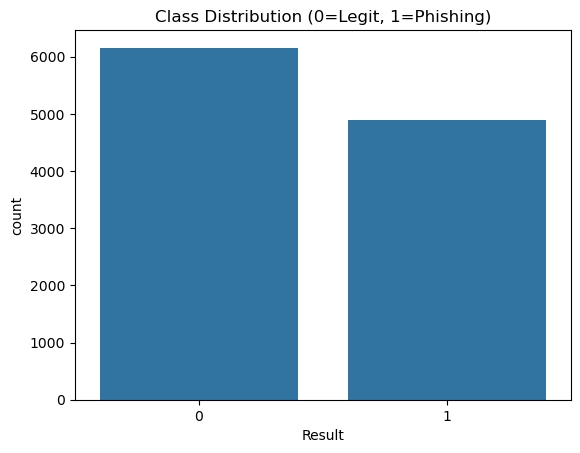

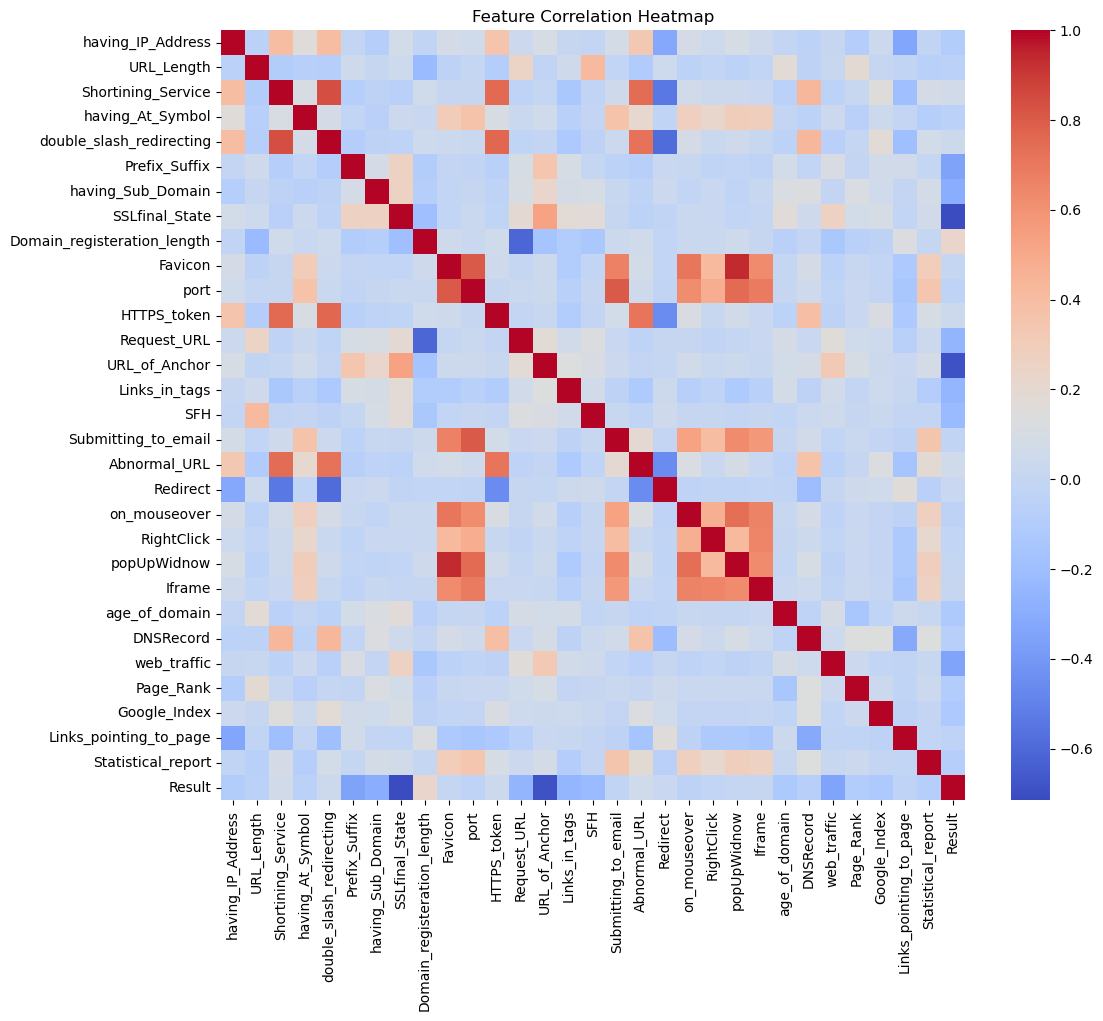

In [15]:
plt.figure()
sns.countplot(x=data["Result"])
plt.title("Class Distribution (0=Legit, 1=Phishing)")
plt.show()

plt.figure(figsize=(12,10))
sns.heatmap(data.corr(), cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Split Data

In [16]:
selected_features = [
    "SSLfinal_State",
    "URL_Length",
    "having_Sub_Domain",
    "Prefix_Suffix",
    "having_At_Symbol"
]

X = data[selected_features]
y = data["Result"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# TRAINING AUTOML

In [18]:
print("\n===== STARTING AUTOML TRAINING =====")

tpot = TPOTClassifier(
    generations=5,
    population_size=30,
    verbose=2,
    random_state=42,
    n_jobs=1,
    max_time_mins=40
)

tpot.fit(X_train, y_train)

print("\n===== AUTOML TRAINING COMPLETED =====")



===== STARTING AUTOML TRAINING =====


C:\Users\admin\AppData\Roaming\Python\Python313\site-packages\tpot\tpot_estimator\estimator.py:458: UserWarning: Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.
  warnings.warn("Both generations and max_time_mins are set. TPOT will terminate when the first condition is met.")
Generation: 100%|███████████████████████████████████████████████████████████████████████| 5/5 [40:00<00:00, 480.13s/it]



===== AUTOML TRAINING COMPLETED =====


# PREDICTIONS


In [19]:

y_pred = tpot.predict(X_test)

print("\n===== AUTOML RESULTS =====")

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


===== AUTOML RESULTS =====
Accuracy: 0.8995929443690638

Confusion Matrix:
[[1166   89]
 [ 133  823]]

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.93      0.91      1255
           1       0.90      0.86      0.88       956

    accuracy                           0.90      2211
   macro avg       0.90      0.89      0.90      2211
weighted avg       0.90      0.90      0.90      2211



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


# ROC CURVE


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


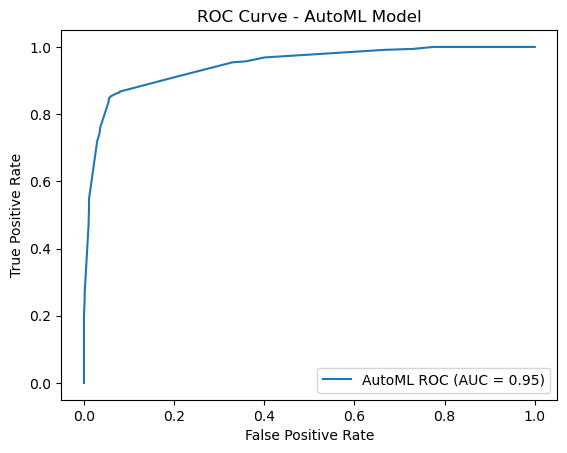

In [20]:

probs = tpot.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label="AutoML ROC (AUC = %0.2f)" % roc_auc)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - AutoML Model")
plt.legend()
plt.show()

# FEATURE IMPORTANCE (IF AVAILABLE)



===== FEATURE IMPORTANCE =====
             Feature  Importance
1         URL_Length         286
4   having_At_Symbol         264
0     SSLfinal_State         252
2  having_Sub_Domain         180
3      Prefix_Suffix         136


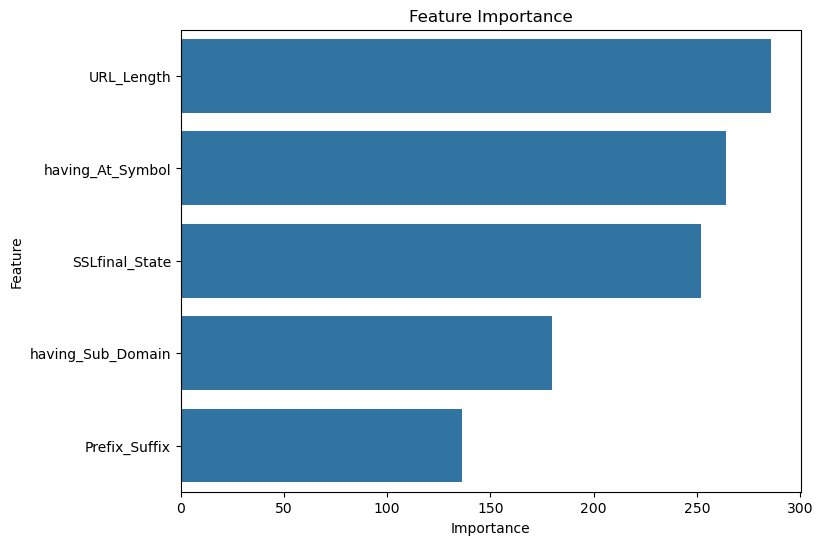

In [21]:

try:
    model = tpot.fitted_pipeline_.steps[-1][1]

    if hasattr(model, "feature_importances_"):
        importance_df = pd.DataFrame({
            "Feature": selected_features,
            "Importance": model.feature_importances_
        }).sort_values(by="Importance", ascending=False)

        print("\n===== FEATURE IMPORTANCE =====")
        print(importance_df)

        plt.figure(figsize=(8,6))
        sns.barplot(
            x="Importance",
            y="Feature",
            data=importance_df
        )
        plt.title("Feature Importance")
        plt.show()

except:
    print("Feature importance not available for this model.")




# SAVE AUTOML MODEL


In [22]:
joblib.dump(tpot.fitted_pipeline_, "automl_model.pkl")

print("\n✅ AutoML model saved as automl_model.pkl")
print("🚀 Project Completed Successfully!")


✅ AutoML model saved as automl_model.pkl
🚀 Project Completed Successfully!
